# Metrics analysis

Loads the per-combo CSV files produced by [`run_sweep.py --output-dir`](run_sweep.py) and
provides small helpers for statistical comparison of any single metric between a
pair of evaluations (combos).

**Setup** (run once in a venv):

```bash
python3 -m venv .venv
source .venv/bin/activate
pip3 install -r requirements.txt
python3 -m ipykernel install --user --name master-diploma --display-name 'master-diploma (.venv)'
jupyter notebook demo/report.ipynb
```

In [1]:
from __future__ import annotations

import math
from itertools import combinations
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from cliffs_delta import cliffs_delta
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda v: f'{v:.4g}')
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)

METRIC_COLUMNS = [
    'orders',
    'conflicts',
    'avg_wait',
    'avg_reverse',
    'avg_speed',
    'avg_order_time',
]

In [2]:
def load_run(csv_path: str | Path) -> pd.DataFrame | None:
    df = pd.read_csv(csv_path, dtype=str, keep_default_na=False)
    if df.size == 0:
        return None
    for col in METRIC_COLUMNS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')
    return df


def load_runs(directory: str | Path, pattern: str = '*.csv') -> dict[str, pd.DataFrame]:
    directory = Path(directory)
    runs: dict[str, pd.DataFrame] = {}
    for path in sorted(directory.glob(pattern)):
        data = load_run(path)
        if data is not None:
            runs[path.stem] = data
    return runs


def overview(runs: dict[str, pd.DataFrame], metric: str) -> pd.DataFrame:
    rows = []
    for label, df in runs.items():
        if metric not in df.columns:
            continue
        series = df[metric].dropna()
        rows.append({
            'combo': label,
            'n': int(series.size),
            'mean': series.mean() if series.size else np.nan,
            'std': series.std(ddof=1) if series.size > 1 else np.nan,
            'min': series.min() if series.size else np.nan,
            'max': series.max() if series.size else np.nan,
        })
    return pd.DataFrame(rows).set_index('combo')

In [3]:
def _delta_magnitude(delta: float) -> str:
    ad = abs(delta)
    if ad < 0.147:
        return 'negligible'
    if ad < 0.33:
        return 'small'
    if ad < 0.474:
        return 'medium'
    return 'large'


def compare_pair(runs: dict[str, pd.DataFrame],
                 combo_a: str, combo_b: str, metric: str) -> pd.Series:
    a = runs[combo_a][metric].dropna().to_numpy()
    b = runs[combo_b][metric].dropna().to_numpy()
    u_stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    delta = cliffs_delta(a, b)[0]
    return pd.Series({
        'metric': metric,
        'a': combo_a,
        'b': combo_b,
        'n_a': int(a.size),
        'n_b': int(b.size),
        'median_a': float(np.median(a)),
        'median_b': float(np.median(b)),
        'mwu_U': float(u_stat),
        'p_value': float(p),
        'cliffs_delta': float(delta),
        'effect': _delta_magnitude(delta),
    })


def compare_pairs(pairs: Iterable[tuple[str, str]],
                  runs: dict[str, pd.DataFrame],
                  metric: str,
                  alpha: float = 0.05) -> pd.DataFrame:
    rows = [compare_pair(runs, a, b, metric) for a, b in pairs]
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    reject, p_adj, *_ = multipletests(out['p_value'].fillna(1.0),
                                      alpha=alpha, method='holm')
    out['p_holm'] = p_adj
    out['significant'] = reject
    return out.sort_values('p_holm').reset_index(drop=True)


def compare_all_pairs(runs: dict[str, pd.DataFrame],
                      metric: str,
                      alpha: float = 0.05) -> pd.DataFrame:
    return compare_pairs(combinations(list(runs.keys()), 2), runs, metric, alpha)

In [4]:
import re
from collections import defaultdict

PRIMARY_METRICS = ['orders', 'avg_order_time', 'avg_speed']
HIGHER_IS_BETTER = {'orders': True, 'avg_order_time': False, 'avg_speed': True}
GRAPH_ORDER = ['small', 'medium', 'large']
AGENTS_ORDER = [10, 50, 100, 500, 1000]
CCBS_AGENTS = [10, 50, 100, 500, 1000]


def parse_combo(name: str) -> dict:
    parts = name.split('_')
    result: dict = {}
    cur_key, cur_val = None, []
    for p in parts:
        if '=' in p and re.match(r'^[A-Za-z_]+=', p):
            if cur_key is not None:
                result[cur_key] = '_'.join(cur_val)
            k, v = p.split('=', 1)
            cur_key, cur_val = k, [v]
        else:
            cur_val.append(p)
    if cur_key is not None:
        result[cur_key] = '_'.join(cur_val)
    g = result.get('graph', '')
    for short in GRAPH_ORDER:
        if short in g:
            result['graph'] = short
            break
    if 'agents' in result:
        result['agents'] = int(result['agents'])
    return result


def select(runs: dict[str, pd.DataFrame], **filters) -> dict[str, pd.DataFrame]:
    out = {}
    for name, df in runs.items():
        meta = parse_combo(name)
        if all(meta.get(k) == v for k, v in filters.items()):
            out[name] = df
    return out


def find_combo(runs: dict[str, pd.DataFrame], **filters) -> str | None:
    sub = select(runs, **filters)
    if not sub:
        return None
    if len(sub) > 1:
        raise ValueError(f'Ambiguous filter {filters}: {list(sub)}')
    return next(iter(sub))


runs = load_runs('reports')

runs_active = {n: df for n, df in runs.items()
               if not (parse_combo(n).get('router') == 'astar'
                       and parse_combo(n).get('resolver') == 'none')}
print(f'loaded {len(runs)} combos, {len(runs_active)} active')
pd.DataFrame([parse_combo(n) for n in sorted(runs_active)]).groupby(
    ['resolver', 'router']).size().rename('n_strata')

/tmp/ipykernel_46452/2723710276.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')
/tmp/ipykernel_46452/2723710276.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')
/tmp/ipykernel_46452/2723710276.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To o

loaded 84 combos, 75 active


/tmp/ipykernel_46452/2723710276.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')
/tmp/ipykernel_46452/2723710276.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = pd.to_numeric(df[col].replace('-', np.nan), errors='coerce')
/tmp/ipykernel_46452/2723710276.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To o

resolver   router
none       ccbs      15
reverse    astar     15
           stat      15
semaphore  astar     15
           stat      15
Name: n_strata, dtype: int64

### §3.1 Per-resolver winner router

Within each stratum `(graph, agents)` and for each resolver
`R ∈ {reverse, semaphore}` compare `astar+R` vs `stat+R` on the three
primary metrics. Holm correction over K=3 per row. Voting rule:

- per metric: `negligible` if `p_holm ≥ 0.05` or `|δ| < 0.147`;
  otherwise the combo with the better median (per metric direction);
- winner: ≥ 2 of 3 votes; 1-1-1 split → priority to `orders` (main KPI);
- all three negligible → `both` (§3.2 will expand to a Cartesian product).

In [5]:
def _vote_winner(row, a_label, b_label) -> str:
    if not row['significant'] or row['effect'] == 'negligible':
        return 'tie'
    higher_better = HIGHER_IS_BETTER[row['metric']]
    a_better = row['cliffs_delta'] > 0 if higher_better else row['cliffs_delta'] < 0
    return a_label if a_better else b_label


def _resolve_votes(votes_by_metric: dict[str, str], a_label, b_label) -> str:
    counts = {a_label: 0, b_label: 0, 'tie': 0}
    for v in votes_by_metric.values():
        counts[v] += 1
    if counts['tie'] == 3:
        return 'both'
    if counts[a_label] >= 2:
        return a_label
    if counts[b_label] >= 2:
        return b_label
    # 1-1-1 split: priority to orders.
    return votes_by_metric.get('orders', 'both')


def compare_routers_for_resolver(runs, graph, agents, resolver):
    a_name = find_combo(runs, graph=graph, agents=agents, resolver=resolver, router='astar')
    b_name = find_combo(runs, graph=graph, agents=agents, resolver=resolver, router='stat')
    if a_name is None or b_name is None:
        return None, None
    pairs = [(a_name, b_name)] * len(PRIMARY_METRICS)
    tables = [compare_pairs([(a_name, b_name)], runs, m) for m in PRIMARY_METRICS]
    # We need joint Holm across the 3 metrics, so reuse multipletests directly.
    raw_rows = [compare_pair(runs, a_name, b_name, m) for m in PRIMARY_METRICS]
    raw = pd.DataFrame(raw_rows)
    reject, p_adj, *_ = multipletests(raw['p_value'].fillna(1.0), alpha=0.05, method='holm')
    raw['p_holm'] = p_adj
    raw['significant'] = reject
    raw['graph'] = graph
    raw['agents'] = agents
    raw['resolver'] = resolver
    raw['vote'] = raw.apply(lambda r: _vote_winner(r, 'astar', 'stat'), axis=1)
    winner = _resolve_votes(dict(zip(raw['metric'], raw['vote'])), 'astar', 'stat')
    return raw, winner

In [6]:
rows_31 = []
winner_router: dict[tuple[str, str, int], str] = {}
for resolver in ('reverse', 'semaphore'):
    for graph in GRAPH_ORDER:
        for agents in AGENTS_ORDER:
            tbl, winner = compare_routers_for_resolver(runs_active, graph, agents, resolver)
            if tbl is None:
                continue
            rows_31.append(tbl)
            winner_router[(resolver, graph, agents)] = winner

table_31 = pd.concat(rows_31, ignore_index=True)[
    ['resolver', 'graph', 'agents', 'metric',
     'median_a', 'median_b', 'cliffs_delta', 'effect',
     'p_holm', 'significant', 'vote']
]

display(table_31)

,resolver,graph,agents,metric,median_a,median_b,cliffs_delta,effect,p_holm,significant,vote
0,reverse,small,10,orders,2013,2018,-0.1906,small,0.01422,True,stat
1,reverse,small,10,avg_order_time,107.3,107,0.1798,small,0.01422,True,stat
2,reverse,small,10,avg_speed,2.063,2.069,-0.9279,large,9.882e-39,True,stat
3,reverse,small,50,orders,9324,9514,-0.9998,large,7.686e-34,True,stat
4,reverse,small,50,avg_order_time,115.8,113.5,0.9996,large,7.686e-34,True,stat
...,...,...,...,...,...,...,...,...,...,...,...
85,semaphore,large,500,avg_order_time,728.2,681.3,1,large,3.081e-09,True,stat
86,semaphore,large,500,avg_speed,2.039,2.144,-1,large,3.081e-09,True,stat
87,semaphore,large,1000,orders,2.81e+04,3.157e+04,-1,large,0.0002464,True,stat
88,semaphore,large,1000,avg_order_time,766,682.8,1,large,0.0002464,True,stat


In [43]:
from tabulate import tabulate

In [69]:
rep = table_31[table_31['resolver'] == 'semaphore'][table_31['metric'] == 'orders'].drop(columns=['resolver', 'significant', 'effect', 'metric'])
print(tabulate(rep, tablefmt='latex', floatfmt='.6g', showindex=False))

\begin{tabular}{lrrrrrl}
\hline
 small  &   10 &  2064.5 &  2064   &  0.0315   & 1           & tie  \\
 small  &  100 & 18081   & 18532   & -1        & 1.80311e-30 & stat \\
 small  &  500 & 57089.5 & 61525   & -1        & 3.8321e-07  & stat \\
 small  & 1000 & 66356   & 88968   & -1        & 2.30548e-07 & stat \\
 medium &   10 &   606   &   608   & -0.0598   & 0.60174     & tie  \\
 medium &  100 &  5942   &  5958   & -0.326316 & 0.00587142  & stat \\
 medium &  500 & 27855.5 & 28502   & -1        & 0.000548015 & stat \\
 medium & 1000 & 51526   & 54194   & -1        & 0.0004662   & stat \\
 large  &   10 &   309.5 &   311   & -0.076025 & 0.376573    & tie  \\
 large  &  100 &  3115   &  3148   & -0.691253 & 2.30415e-08 & stat \\
 large  &  500 & 14783   & 15579.5 & -1        & 0.000246812 & stat \\
 large  & 1000 & 28123   & 30937.5 & -1        & 0.0034965   & stat \\
\hline
\end{tabular}


/tmp/ipykernel_67029/2584628733.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rep = table_31[table_31['resolver'] == 'semaphore'][table_31['metric'] == 'orders'].drop(columns=['resolver', 'significant', 'effect', 'metric'])


In [7]:
# §3.1 explicit winner matrices: per resolver, per metric — and overall.
table_31_full = pd.concat(rows_31, ignore_index=True)


def _winner_label_31(row):
    if not row['significant'] or row['effect'] == 'negligible':
        return 'tie'
    higher_better = HIGHER_IS_BETTER[row['metric']]
    a_better = row['cliffs_delta'] > 0 if higher_better else row['cliffs_delta'] < 0
    return 'astar' if a_better else 'stat'


table_31_full['winner_metric'] = table_31_full.apply(_winner_label_31, axis=1)

for resolver in ('reverse', 'semaphore'):
    sub = table_31_full[table_31_full['resolver'] == resolver]
    print(f'\n=== resolver = {resolver} ===')
    for metric in PRIMARY_METRICS:
        mat = (sub[sub['metric'] == metric]
               .pivot(index='graph', columns='agents', values='winner_metric')
               .reindex(index=GRAPH_ORDER, columns=AGENTS_ORDER))
        print(f'winner router by {metric}:')
        display(mat)
    # Overall (majority vote) matrix.
    overall = pd.DataFrame(index=GRAPH_ORDER, columns=AGENTS_ORDER, dtype=object)
    for (r, g, a), w in winner_router.items():
        if r == resolver:
            overall.loc[g, a] = w
    print('overall winner (majority vote, 3 metrics):')
    display(overall)


=== resolver = reverse ===
winner router by orders:


agents,10,50,100,500,1000
graph,,,,,
small,stat,stat,stat,stat,stat
medium,tie,stat,stat,stat,stat
large,stat,stat,stat,stat,stat


winner router by avg_order_time:


agents,10,50,100,500,1000
graph,,,,,
small,stat,stat,stat,stat,stat
medium,tie,stat,stat,stat,stat
large,stat,stat,stat,stat,stat


winner router by avg_speed:


...

agents,10,50,100,500,1000
graph,,,,,
small,tie,stat,stat,stat,stat
medium,tie,stat,stat,stat,stat
large,stat,stat,stat,stat,stat


winner router by avg_speed:


agents,10,50,100,500,1000
graph,,,,,
small,stat,stat,stat,stat,stat
medium,stat,stat,stat,stat,stat
large,stat,stat,stat,stat,stat


overall winner (majority vote, 3 metrics):


,10,50,100,500,1000
small,tie,stat,stat,stat,stat
medium,tie,stat,stat,stat,stat
large,stat,stat,stat,stat,stat


### §3.2 `reverse` vs `semaphore` in best-router configurations

Per stratum take the winner router from §3.1 for each resolver and run
a single pair `(astar|stat)+reverse` vs `(astar|stat)+semaphore`. When
§3.1 returns `both` for a resolver the pair is expanded to the Cartesian
product (1, 2 or 4 pairs per stratum); all pairs of a stratum share one
Holm family of size `3 · #pairs`.

In [8]:
def _routers_for(resolver, graph, agents):
    return ['stat']
    # w = winner_router.get((resolver, graph, agents))
    # if w == 'both':
    #     return ['astar', 'stat']
    # return [w] if w else []


rows_32 = []
summary_32 = []
for graph in GRAPH_ORDER:
    for agents in AGENTS_ORDER:
        rev_routers = _routers_for('reverse', graph, agents)
        sem_routers = _routers_for('semaphore', graph, agents)
        if not rev_routers or not sem_routers:
            continue
        stratum_rows = []
        for r_router in rev_routers:
            for s_router in sem_routers:
                a_name = find_combo(runs_active, graph=graph, agents=agents,
                                    resolver='reverse', router=r_router)
                b_name = find_combo(runs_active, graph=graph, agents=agents,
                                    resolver='semaphore', router=s_router)
                if not a_name or not b_name:
                    continue
                for m in PRIMARY_METRICS:
                    s = compare_pair(runs_active, a_name, b_name, m)
                    s['graph'] = graph
                    s['agents'] = agents
                    s['router_reverse'] = r_router
                    s['router_semaphore'] = s_router
                    stratum_rows.append(s)
        if not stratum_rows:
            continue
        df = pd.DataFrame(stratum_rows)
        reject, p_adj, *_ = multipletests(df['p_value'].fillna(1.0),
                                          alpha=0.05, method='holm')
        df['p_holm'] = p_adj
        df['significant'] = reject
        df['vote'] = df.apply(lambda r: _vote_winner(r, 'reverse', 'semaphore'), axis=1)
        rows_32.append(df)
        votes = df['vote'].tolist()
        counts = {'reverse': votes.count('reverse'),
                  'semaphore': votes.count('semaphore'),
                  'tie': votes.count('tie')}
        if counts['reverse'] > counts['semaphore'] and counts['reverse'] > counts['tie']:
            winner = 'reverse'
        elif counts['semaphore'] > counts['reverse'] and counts['semaphore'] > counts['tie']:
            winner = 'semaphore'
        elif counts['reverse'] == counts['semaphore'] and counts['reverse'] > 0:
            winner = 'mixed'
        else:
            winner = 'tie'
        summary_32.append({
            'graph': graph, 'agents': agents,
            'winner': winner,
            'votes_reverse': counts['reverse'],
            'votes_semaphore': counts['semaphore'],
            'votes_tie': counts['tie'],
            'votes_total': len(votes),
            'abs_delta_median': float(df['cliffs_delta'].abs().median()),
            'n_pairs': int(len(df[df['metric'] == 'orders'])),
        })

table_32 = pd.concat(rows_32, ignore_index=True)[
    ['graph', 'agents', 'router_reverse', 'router_semaphore', 'metric',
     'median_a', 'median_b', 'cliffs_delta', 'effect',
     'p_holm', 'significant', 'vote']
]
table_32

,graph,agents,router_reverse,router_semaphore,metric,median_a,median_b,cliffs_delta,effect,p_holm,significant,vote
0,small,10,stat,stat,orders,2018,2067,-0.9668,large,7.112e-32,True,semaphore
1,small,10,stat,stat,avg_order_time,107,104.4,0.964,large,7.112e-32,True,semaphore
2,small,10,stat,stat,avg_speed,2.069,2.077,-0.9694,large,7.112e-32,True,semaphore
3,small,50,stat,stat,orders,9514,9785,-1,large,7.64e-34,True,semaphore
4,small,50,stat,stat,avg_order_time,113.5,110.3,1,large,7.64e-34,True,semaphore
5,small,50,stat,stat,avg_speed,2.018,2.007,0.9994,large,7.64e-34,True,reverse
6,small,100,stat,stat,orders,1.846e+04,1.866e+04,-0.9415,large,5.505e-25,True,semaphore
7,small,100,stat,stat,avg_order_time,117,115.8,0.9457,large,5.505e-25,True,semaphore
8,small,100,stat,stat,avg_speed,1.993,1.968,1,large,1.334e-27,True,reverse
9,small,500,stat,stat,orders,7.342e+04,6.103e+04,1,large,8.479e-14,True,reverse


In [72]:
rep = table_32[table_32['metric'] == 'avg_order_time'].drop(columns=['router_reverse', 'router_semaphore', 'significant', 'effect', 'metric'])
print(tabulate(rep, tablefmt='latex', floatfmt='.4g', showindex=False))

\begin{tabular}{lrrrrrl}
\hline
 small  &   10 & 107.3 & 104.6 &  0.9537  & 6.448e-61 & semaphore \\
 small  &  100 & 117.3 & 116.5 &  0.8381  & 5.153e-21 & semaphore \\
 small  &  500 & 149.2 & 175.3 & -1       & 1.245e-05 & reverse   \\
 small  & 1000 & 168.4 & 242.5 & -1       & 8.368e-05 & reverse   \\
 medium &   10 & 354.6 & 355.1 & -0.01965 & 1         & tie       \\
 medium &  100 & 367.5 & 362.3 &  0.95    & 1.141e-19 & semaphore \\
 medium &  500 & 383.6 & 378.6 &  1       & 0.0003085 & semaphore \\
 medium & 1000 & 395.6 & 398.1 & -1       & 0.01212   & reverse   \\
 large  &   10 & 695.7 & 693.6 &  0.0467  & 1         & tie       \\
 large  &  100 & 689.4 & 684.8 &  0.4373  & 0.0002832 & semaphore \\
 large  &  500 & 700.7 & 691.3 &  0.9286  & 0.002486  & semaphore \\
 large  & 1000 & 701.1 & 696.5 &  1       & 0.02857   & semaphore \\
\hline
\end{tabular}


In [9]:
# §3.2 explicit winner matrices: per metric + overall (majority vote).
summary_32_df = pd.DataFrame(summary_32)
all_32_now = pd.concat(rows_32, ignore_index=True)

# Per-metric winner per (graph, agents): mode of per-pair votes within stratum.
def _stratum_metric_winner(group):
    votes = group['vote'].tolist()
    if not votes:
        return 'n/a'
    r = votes.count('reverse')
    s = votes.count('semaphore')
    t = votes.count('tie')
    if r > s and r > t:
        return 'reverse'
    if s > r and s > t:
        return 'semaphore'
    if r == s and r > 0:
        return 'mixed'
    return 'tie'


for metric in PRIMARY_METRICS:
    per_metric = (all_32_now[all_32_now['metric'] == metric]
                  .groupby(['graph', 'agents'])
                  .apply(_stratum_metric_winner)
                  .unstack('agents')
                  .reindex(index=GRAPH_ORDER, columns=AGENTS_ORDER))
    print(f'§3.2 winner by {metric}:')
    display(per_metric)

winner_matrix = summary_32_df.pivot(index='graph', columns='agents',
                                    values='winner').reindex(
    index=GRAPH_ORDER, columns=AGENTS_ORDER)
delta_matrix = summary_32_df.pivot(index='graph', columns='agents',
                                   values='abs_delta_median').reindex(
    index=GRAPH_ORDER, columns=AGENTS_ORDER)
print('§3.2 overall stratum winner (majority vote across all primary metrics):')
display(winner_matrix)

§3.2 winner by orders:


/tmp/ipykernel_46452/66244299.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_stratum_metric_winner)


agents,10,50,100,500,1000
graph,,,,,
small,semaphore,semaphore,semaphore,reverse,reverse
medium,tie,semaphore,semaphore,semaphore,tie
large,tie,tie,semaphore,semaphore,semaphore


§3.2 winner by avg_order_time:


/tmp/ipykernel_46452/66244299.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_stratum_metric_winner)


...

§3.2 winner by avg_speed:


/tmp/ipykernel_46452/66244299.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_stratum_metric_winner)


agents,10,50,100,500,1000
graph,,,,,
small,semaphore,reverse,reverse,reverse,reverse
medium,semaphore,semaphore,semaphore,reverse,reverse
large,tie,tie,tie,reverse,reverse


§3.2 overall stratum winner (majority vote across all primary metrics):


agents,10,50,100,500,1000
graph,,,,,
small,semaphore,semaphore,semaphore,reverse,reverse
medium,tie,semaphore,semaphore,semaphore,tie
large,tie,tie,semaphore,semaphore,semaphore


### §3.3 `ccbs+none` vs best lifelong configurations

Restricted to `agents ∈ {10, 100, 1000}`. Per stratum two pairs
(`ccbs` vs best-reverse, `ccbs` vs best-semaphore) × three primary
metrics, all six tests in one Holm family. `avg_wait` is reported as a
qualitative side comment without Holm.

In [10]:
rows_33 = []
wait_rows_33 = []
for graph in GRAPH_ORDER:
    for agents in CCBS_AGENTS:
        ccbs = find_combo(runs, graph=graph, agents=agents,
                          router='ccbs', resolver='none')
        if not ccbs:
            continue
        stratum_rows = []
        for resolver in ('reverse', 'semaphore'):
            for r in _routers_for(resolver, graph, agents):
                cand = find_combo(runs_active, graph=graph, agents=agents,
                                  resolver=resolver, router=r)
                if not cand:
                    continue
                for m in PRIMARY_METRICS:
                    s = compare_pair(runs, ccbs, cand, m)
                    s['graph'] = graph
                    s['agents'] = agents
                    s['candidate_resolver'] = resolver
                    s['candidate_router'] = r
                    stratum_rows.append(s)
        if not stratum_rows:
            continue
        df = pd.DataFrame(stratum_rows)
        reject, p_adj, *_ = multipletests(df['p_value'].fillna(1.0),
                                          alpha=0.05, method='holm')
        df['p_holm'] = p_adj
        df['significant'] = reject
        df['vote'] = df.apply(lambda r: _vote_winner(r, 'ccbs', 'lifelong'), axis=1)
        rows_33.append(df)

table_33 = pd.concat(rows_33, ignore_index=True)[
    ['graph', 'agents', 'candidate_resolver', 'candidate_router', 'metric',
     'median_a', 'median_b', 'cliffs_delta', 'effect',
     'p_holm', 'significant', 'vote']
]
table_33

,graph,agents,candidate_resolver,candidate_router,metric,median_a,median_b,cliffs_delta,effect,p_holm,significant,vote
0,small,10,reverse,stat,orders,1981,2018,-0.8975,large,1.466e-36,True,lifelong
1,small,10,reverse,stat,avg_order_time,109,107,0.8951,large,1.466e-36,True,lifelong
2,small,10,reverse,stat,avg_speed,2.002,2.069,-1,large,1.464e-44,True,lifelong
3,small,10,semaphore,stat,orders,1981,2067,-1,large,1.464e-44,True,lifelong
4,small,10,semaphore,stat,avg_order_time,109,104.4,1,large,1.464e-44,True,lifelong
...,...,...,...,...,...,...,...,...,...,...,...,...
85,large,1000,reverse,stat,avg_order_time,685.5,687.5,-0.5065,large,0.1385,False,tie
86,large,1000,reverse,stat,avg_speed,2.139,2.146,-1,large,0.0003771,True,lifelong
87,large,1000,semaphore,stat,orders,3.145e+04,3.157e+04,-0.5556,large,0.1336,False,tie
88,large,1000,semaphore,stat,avg_order_time,685.5,682.8,0.5758,large,0.1336,False,tie


In [82]:
rep = table_33[((table_33['graph'] == 'small') & (table_33['agents'] == 10)) | ((table_33['graph'] == 'medium') & (table_33['agents'] == 100)) | ((table_33['graph'] == 'large') & (table_33['agents'] == 1000))].drop(columns=['candidate_router', 'significant', 'effect', 'median_a', 'median_b'])
rep
print(tabulate(rep, tablefmt='latex', floatfmt='.4g', showindex=False))

\begin{tabular}{lrllrrl}
\hline
 small  &   10 & reverse   & orders         & -0.8222 & 1.087e-45 & lifelong \\
 small  &   10 & reverse   & avg\_order\_time &  0.823  & 1.087e-45 & lifelong \\
 small  &   10 & reverse   & avg\_speed      & -1      & 2.837e-66 & lifelong \\
 small  &   10 & semaphore & orders         & -1      & 2.837e-66 & lifelong \\
 small  &   10 & semaphore & avg\_order\_time &  1      & 2.837e-66 & lifelong \\
 small  &   10 & semaphore & avg\_speed      & -1      & 2.837e-66 & lifelong \\
 medium &  100 & reverse   & orders         &  0.129  & 1         & tie      \\
 medium &  100 & reverse   & avg\_order\_time & -0.1468 & 1         & tie      \\
 medium &  100 & reverse   & avg\_speed      & -1      & 4.14e-09  & lifelong \\
 medium &  100 & semaphore & orders         & -0.974  & 9.55e-05  & lifelong \\
 medium &  100 & semaphore & avg\_order\_time &  0.9636 & 7.32e-07  & lifelong \\
 medium &  100 & semaphore & avg\_speed      & -1      & 2.033e-08 & lifelong

#### §3.3 overall summary

Aggregates the per-stratum `ccbs+none` vs best-lifelong comparisons into
a winner matrix (rows = graph size, columns = agents count) for each
candidate resolver. Cell value is the clear winner per stratum decided
by majority of per-metric votes (Holm-corrected, negligible effects
count as ties):

- `ccbs` — offline CCBS beats lifelong on the majority of metrics;
- `lifelong` — lifelong configuration beats ccbs;
- `mixed` — equal split between ccbs and lifelong wins;
- `tie` — all metrics negligible / not significant.

A one-line verdict per resolver follows the matrices.

In [11]:
# §3.3 summary as matrix: rows = graph, cols = agents, cell = clear winner
# (per candidate resolver). Winner per stratum = majority of per-metric votes
# (Holm-corrected) between ccbs+none and the best lifelong configuration.
if not rows_33:
    print('§3.3 has no rows (ccbs data missing).')
else:
    all_33_local = pd.concat(rows_33, ignore_index=True)

    def _stratum_winner(group):
        votes = group['vote'].tolist()
        if not votes:
            return 'n/a'
        c = votes.count('ccbs')
        l = votes.count('lifelong')
        n = votes.count('negligible') + votes.count('tie')
        if c > l and c > n:
            return 'ccbs'
        if l > c and l > n:
            return 'lifelong'
        if c == l and c > 0:
            return 'mixed'
        return 'tie'

    for resolver in ('reverse', 'semaphore'):
        sub = all_33_local[all_33_local['candidate_resolver'] == resolver]
        if sub.empty:
            print(f'§3.3 no data for candidate resolver = {resolver}')
            continue
        matrix = (sub.groupby(['graph', 'agents'])
                     .apply(_stratum_winner)
                     .unstack('agents')
                     .reindex(index=GRAPH_ORDER, columns=CCBS_AGENTS))
        print(f'§3.3 stratum winner: ccbs+none vs best-lifelong+{resolver}')
        display(matrix.fillna('n/a'))

    # Overall verdict across both candidates.
    print('§3.3 VERDICT (majority of per-test votes):')
    for resolver in ('reverse', 'semaphore'):
        sub = all_33_local[all_33_local['candidate_resolver'] == resolver]
        if sub.empty:
            continue
        tally = sub['vote'].value_counts()
        n = int(tally.sum())
        ccbs_w = int(tally.get('ccbs', 0))
        life_w = int(tally.get('lifelong', 0))
        ties = n - ccbs_w - life_w
        if ccbs_w > life_w and ccbs_w > ties:
            v = f'ccbs dominates ({ccbs_w}/{n} tests)'
        elif life_w > ccbs_w and life_w > ties:
            v = f'lifelong+{resolver} dominates ({life_w}/{n} tests)'
        else:
            v = (f'no winner: ccbs={ccbs_w}, lifelong={life_w}, '
                 f'tie/negligible={ties} of {n}')
        print(f'  vs {resolver:>9}: {v}')


§3.3 stratum winner: ccbs+none vs best-lifelong+reverse


/tmp/ipykernel_46452/3856380600.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_stratum_winner)


agents,10,50,100,500,1000
graph,,,,,
small,lifelong,lifelong,lifelong,lifelong,lifelong
medium,lifelong,tie,tie,lifelong,lifelong
large,tie,tie,tie,ccbs,tie


§3.3 stratum winner: ccbs+none vs best-lifelong+semaphore


/tmp/ipykernel_46452/3856380600.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_stratum_winner)


agents,10,50,100,500,1000
graph,,,,,
small,lifelong,lifelong,lifelong,lifelong,lifelong
medium,lifelong,lifelong,lifelong,lifelong,lifelong
large,tie,tie,tie,tie,tie


§3.3 VERDICT (majority of per-test votes):
  vs   reverse: lifelong+reverse dominates (29/45 tests)
  vs semaphore: lifelong+semaphore dominates (30/45 tests)


### metric(agents) curves

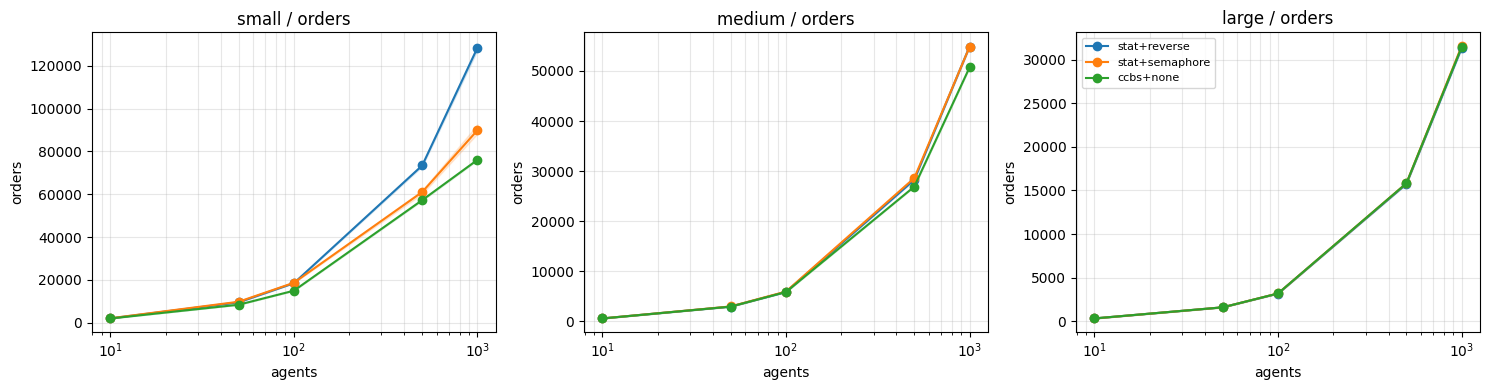

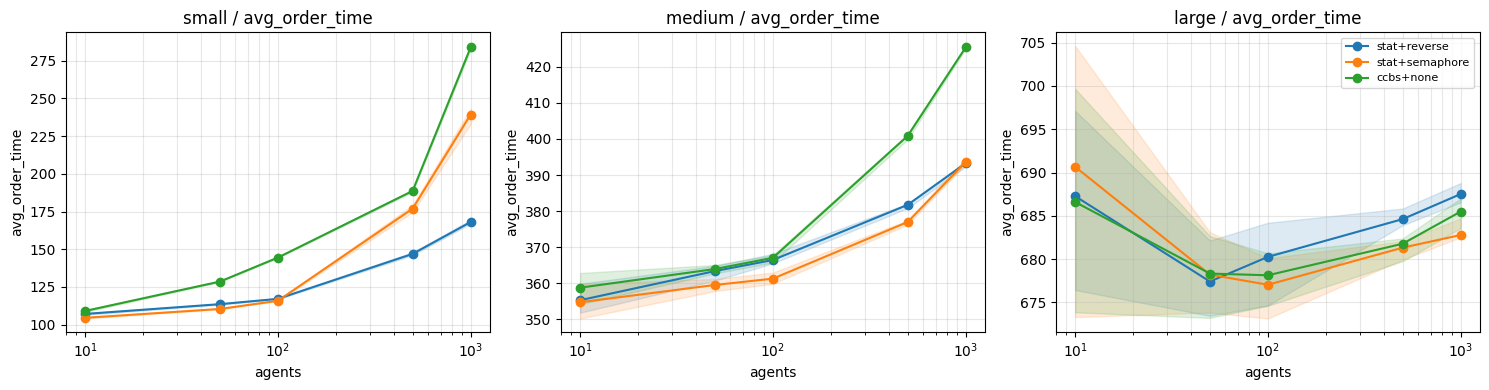

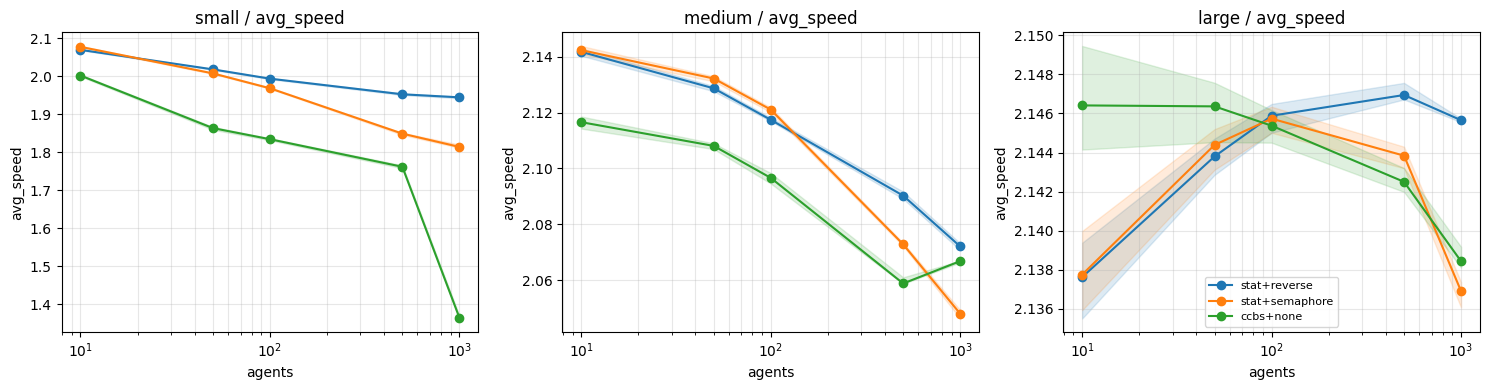

In [ ]:
import matplotlib.pyplot as plt


def _curve_data(runs, graph, router, resolver, metric):
    pts = []
    for n_agents in sorted(AGENTS_ORDER + [a for a in CCBS_AGENTS if a not in AGENTS_ORDER]):
        name = find_combo(runs, graph=graph, agents=n_agents,
                          router=router, resolver=resolver)
        if not name or metric not in runs[name].columns:
            continue
        s = runs[name][metric].dropna()
        if s.empty:
            continue
        pts.append((n_agents, s.quantile(0.25), s.median(), s.quantile(0.75)))
    if not pts:
        return None
    arr = np.array(pts)
    return arr[:, 0], arr[:, 1], arr[:, 2], arr[:, 3]


CURVE_CONFIGS = [
    ('stat', 'reverse'),
    ('stat', 'semaphore'),
    ('ccbs', 'none'),
]

for metric in PRIMARY_METRICS:
    fig, axes = plt.subplots(1, len(GRAPH_ORDER), figsize=(5 * len(GRAPH_ORDER), 4),
                              sharey=False)
    for ax, graph in zip(axes, GRAPH_ORDER):
        for router, resolver in CURVE_CONFIGS:
            data = _curve_data(runs, graph, router, resolver, metric)
            if data is None:
                continue
            xs, q25, med, q75 = data
            label = f'{router}+{resolver}'
            line, = ax.plot(xs, med, marker='o', label=label)
            ax.fill_between(xs, q25, q75, alpha=0.15, color=line.get_color())
        ax.set_xscale('log')
        ax.set_title(f'{graph} / {metric}')
        ax.set_xlabel('agents')
        ax.set_ylabel(metric)
        ax.grid(True, which='both', alpha=0.3)
    axes[-1].legend(loc='best', fontsize=8)
    fig.tight_layout()
    plt.show()

In [ ]:
find_combo()

{'agents=1000_duration=43200_ewma-tau=100_graph=maps_small_map.geojson_max-age=500_resolver=reverse_router=stat':    duration router agents                   graph resolver ewma-tau max-age  \
 0     43200   stat   1000  maps/small_map.geojson  reverse      100     500   
 1     43200   stat   1000  maps/small_map.geojson  reverse      100     500   
 2     43200   stat   1000  maps/small_map.geojson  reverse      100     500   
 3     43200   stat   1000  maps/small_map.geojson  reverse      100     500   
 4     43200   stat   1000  maps/small_map.geojson  reverse      100     500   
 5     43200   stat   1000  maps/small_map.geojson  reverse      100     500   
 6     43200   stat   1000  maps/small_map.geojson  reverse      100     500   
 7     43200   stat   1000  maps/small_map.geojson  reverse      100     500   
 8     43200   stat   1000  maps/small_map.geojson  reverse      100     500   
 9     43200   stat   1000  maps/small_map.geojson  reverse      100     500   
 10    

In [37]:
dfs = dict()

for agents in AGENTS_ORDER:
    for graph in GRAPH_ORDER:
        dfs.update(select(runs, agents=agents, graph=graph, router='stat', resolver='semaphore'))
        dfs.update(select(runs, agents=agents, graph=graph, router='ccbs'))

dfs = list(dfs.values())

In [ ]:
def trasform(df: pd.DataFrame):
    series = []
    metrics = dict()
    for metric in METRIC_COLUMNS:
        metric_clm = df[metric].dropna().to_numpy()
        series.append(
            pd.Series({
                'graph': df['graph'].iloc[0],
                'agents': df['agents'].iloc[0],
                'conf': df['router'].iloc[0] + ' + ' + df['resolver'].iloc[0],
                'metric_name': metric,
                'metric': np.median()
            })
        )


df = pd.concat(dfs)

In [41]:
df['graph'].iloc[0]

'maps/small_map.geojson'

In [38]:
df.head()

,duration,router,agents,graph,resolver,ewma-tau,max-age,rc,time_s,orders,conflicts,avg_wait,avg_reverse,avg_speed,avg_order_time,sim_speed
0,43200,stat,10,maps/small_map.geojson,semaphore,100,500,0,0.664,2054,NaN,13.41,NaN,2.075,105.1,146175.756
1,43200,stat,10,maps/small_map.geojson,semaphore,100,500,0,0.599,2076,NaN,14.31,NaN,2.072,104,149007.055
2,43200,stat,10,maps/small_map.geojson,semaphore,100,500,0,0.654,2108,NaN,13.7,NaN,2.08,102.4,142764.244
3,43200,stat,10,maps/small_map.geojson,semaphore,100,500,0,0.597,2062,NaN,13.86,NaN,2.077,104.7,147572.963
4,43200,stat,10,maps/small_map.geojson,semaphore,100,500,0,0.587,2079,NaN,14.08,NaN,2.076,103.9,149005.051


In [ ]:
sns.catplot(df)